In [1]:
import os, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn import tree
from sklearn import svm

warnings.filterwarnings("ignore")



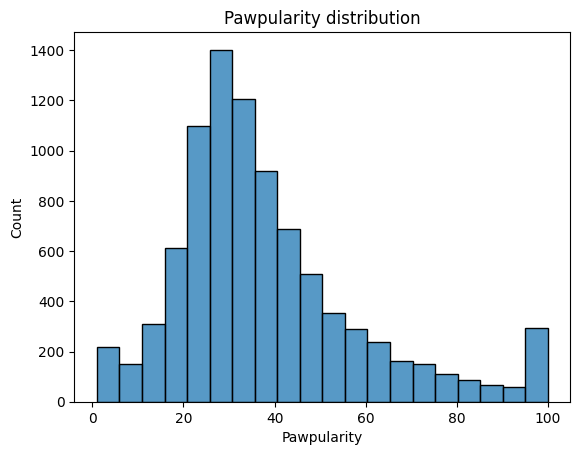

In [2]:
# Load data – keep test order unchanged for correct submission alignment
train_path = "/kaggle/input/petfinder-pawpularity-score/train.csv"
test_path = "/kaggle/input/petfinder-pawpularity-score/test.csv"

train_data = (
    pd.read_csv(train_path).sample(frac=1, random_state=0).reset_index(drop=True)
)
test_data = pd.read_csv(test_path)  # no shuffling

# Optional visual check
sns.histplot(train_data["Pawpularity"], kde=False, bins=20)
plt.title("Pawpularity distribution")
plt.show()




In [3]:
def classification(vals):
    if vals <= 10:
        return 1
    elif 10 < vals <= 20:
        return 2
    elif 20 < vals <= 30:
        return 3
    elif 30 < vals <= 40:
        return 4
    elif 40 < vals <= 50:
        return 5
    elif 50 < vals <= 60:
        return 6
    elif 60 < vals <= 70:
        return 7
    elif 70 < vals <= 80:
        return 8
    elif 80 < vals <= 90:
        return 9
    else:
        return 10


train_data["class"] = train_data["Pawpularity"].apply(classification)



In [4]:
# Feature matrices
x = np.array(train_data.iloc[:, 1:13])  # columns 1‑12 (features)
x_test = np.array(test_data.iloc[:, 1:])  # same feature columns for test
y = np.array(train_data["Pawpularity"])



In [5]:
# Train/validation split
x_train, x_valid, y_train, y_valid = train_test_split(
    x, y, test_size=0.1, random_state=123
)



In [6]:
# XGBoost
xgb_model = xgb.XGBRegressor(
    base_score=0.5,
    booster="gbtree",
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0,
    gpu_id=-1,
    learning_rate=0.3,
    max_depth=1,
    min_child_weight=1,
    n_estimators=200,
    n_jobs=2,
    random_state=0,
    reg_alpha=0,
    reg_lambda=1,
    subsample=1,
    tree_method="exact",
)
xgb_model.fit(x_train, y_train)
p1 = xgb_model.predict(x_test)
a1 = xgb_model.predict(x_valid)
w1 = np.sqrt(mean_squared_error(a1, y_valid))



In [7]:
# Random Forest
rf_model = RandomForestRegressor(
    random_state=123,
    max_depth=10,
    min_samples_leaf=11,
    n_estimators=200,
    min_samples_split=2,
    n_jobs=2,
)
rf_model.fit(x_train, y_train)
p2 = rf_model.predict(x_test)
a2 = rf_model.predict(x_valid)
w2 = np.sqrt(mean_squared_error(a2, y_valid))



In [8]:
# LightGBM (fixed verbose argument)
lgb_model = lgb.LGBMRegressor(
    learning_rate=0.0001,
    max_depth=10,
    min_child_samples=20,
    min_child_weight=0.001,
    num_leaves=31,
    reg_alpha=0,
    reg_lambda=1,
    n_estimators=200,
    n_jobs=2,
    random_state=123,
)
lgb_model.fit(x_train, y_train)  # no verbose parameter
p3 = lgb_model.predict(x_test)
a3 = lgb_model.predict(x_valid)
w3 = np.sqrt(mean_squared_error(a3, y_valid))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 8028, number of used features: 12
[LightGBM] [Info] Start training from score 37.941330


In [9]:
# MLP Neural Network
mlp_model = MLPRegressor(
    hidden_layer_sizes=(10, 10, 10, 10),
    activation="relu",
    solver="adam",
    early_stopping=True,
    max_iter=200,
    random_state=123,
    n_iter_no_change=10,
    verbose=False,
)
mlp_model.fit(x_train, y_train)
p4 = mlp_model.predict(x_test)
a4 = mlp_model.predict(x_valid)
w4 = np.sqrt(mean_squared_error(a4, y_valid))



In [10]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)
p5 = lin_model.predict(x_test)
a5 = lin_model.predict(x_valid)
w5 = np.sqrt(mean_squared_error(a5, y_valid))



In [11]:
# Decision Tree
dt_model = tree.DecisionTreeRegressor(random_state=123)
dt_model.fit(x_train, y_train)
p6 = dt_model.predict(x_test)
a6 = dt_model.predict(x_valid)
w6 = np.sqrt(mean_squared_error(a6, y_valid))



In [12]:
# Support Vector Regressor
svr_model = svm.SVR(C=1, epsilon=0.1, degree=3)
svr_model.fit(x_train, y_train)
p7 = svr_model.predict(x_test)
a7 = svr_model.predict(x_valid)
w7 = np.sqrt(mean_squared_error(a7, y_valid))



In [13]:
# (Optional) display individual RMSEs
rmse_df = pd.DataFrame(
    {
        "Model": [
            "XGBoost",
            "RandomForest",
            "LightGBM",
            "MLP",
            "Linear",
            "DecisionTree",
            "SVR",
        ],
        "RMSE": [w1, w2, w3, w4, w5, w6, w7],
    }
).sort_values("RMSE")
print(rmse_df)



          Model       RMSE
1  RandomForest  21.603726
0       XGBoost  21.618958
4        Linear  21.619775
2      LightGBM  21.639019
3           MLP  21.664718
5  DecisionTree  21.842657
6           SVR  22.297088


In [14]:
# Simple adjustment array (can be tuned later)
p8 = np.array(
    [
        70.23018913764079,
        47.936271096634556,
        48.85761357930474,
        46.358268350017966,
        41.75953959340538,
        25.825420084199322,
        0.7822884587224053,
        38.75711840766357,
    ]
)



In [15]:
# Assemble all predictions; align lengths (p8 may be shorter, pad if needed)
preds_list = [p1, p2, p3, p4, p5, p6, p7]

# If p8 length differs from test size, repeat or truncate to match
if len(p8) != len(p1):
    if len(p8) < len(p1):
        repeats = int(np.ceil(len(p1) / len(p8)))
        p8_extended = np.tile(p8, repeats)[: len(p1)]
    else:
        p8_extended = p8[: len(p1)]
else:
    p8_extended = p8

preds_list.append(p8_extended)

# Compute mean prediction across models
final_pred = np.mean(np.column_stack(preds_list), axis=1)



In [16]:
# Build submission dataframe with correct column names
submission = pd.concat(
    [
        test_data.iloc[:, [0]].reset_index(drop=True),  # Id column
        pd.DataFrame(np.round(final_pred, 8), columns=["Pawpularity"]),
    ],
    axis=1,
)

# Verify shape
assert submission.shape[0] == test_data.shape[0], "Row count mismatch!"



In [17]:
# Save to CSV
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}")

Submission file saved to submission.csv
